# DeepLense Common Task I — Physics-Informed DenseNet161 (Tier-1 optimized)

This notebook is a DenseNet-only, submission-oriented pipeline for **Common Task I** and now includes the full **Tier-1 improvements** we discussed.

## What this notebook does
- Merges the provided `train/` and `val/` folders and rebuilds a **fresh stratified 90:10 split**.
- Uses **DenseNet161** as the main backbone.
- Uses a **physics-informed 3-channel input**:
  1. **asinh-stretched raw channel** for faint-arc visibility,
  2. **LensPINN-style edge channel** for localized perturbations,
  3. **high-pass residual channel** for substructure-sensitive morphology.
- Uses a **small-image stem** for DenseNet:
  - replaces the aggressive ImageNet-style `7×7, stride 2` entry convolution with a **`3×3, stride 1`** stem,
  - removes the initial max-pool,
  - preserves more spatial detail at **150×150** resolution where small substructure cues matter.
- Uses **`catavgmax` global pooling** so the classifier sees both:
  - average/global morphology,
  - strongest localized responses.
- Trains for **up to 40 epochs** with **patience 10** instead of stopping too early.
- Saves the **top-k checkpoints** and performs **top-k checkpoint ensembling** at final evaluation.
- Uses **D4 symmetry augmentation** in training and **D4 test-time augmentation (TTA)** in inference.
- Tracks **validation loss, accuracy, macro-F1, macro AUC, weighted AUC**, and **per-class AUC**.

## Why these changes
Your earlier notebook was already strong, so the goal here is **not** to rewrite DenseNet. The best next improvements are the ones that preserve the good baseline while giving the model a better chance to capture subtle lensing structure.

### 1) Small-image stem
DenseNet backbones pretrained on ImageNet start with early downsampling. That is good for large natural images, but for **150×150 lensing maps** it can throw away fine perturbations too early.  
This notebook replaces that stem with a gentler **`3×3 / stride 1`** entry and removes the first max-pool so more substructure survives into the dense blocks.

### 2) `catavgmax` pooling
For this task, some evidence is diffuse and global, while some evidence is highly localized.  
`catavgmax` pooling gives the head access to **both** kinds of cues instead of forcing a single average-pooled summary.

### 3) Longer training with moderate patience
Your curves were still improving late, so this version increases the training budget to **40 epochs** and uses **patience 10**.  
This is safer than making the optimizer much more aggressive.

### 4) Top-k checkpoint ensemble + D4 TTA
This is one of the most reliable inference-time upgrades:
- keep the best few checkpoints instead of trusting one epoch only,
- average predictions from multiple symmetry-equivalent views at inference.

That usually improves stability and often lifts macro AUC a bit without changing the training data.

## Submission note
Because the provided folder split was not 90:10, this notebook rebuilds a **fresh stratified 90:10 split** from the full labeled dataset so the reported validation metrics match the stated requirement.

In [1]:

# P100-safe: do NOT upgrade torch / torchvision / torchaudio here
!pip -q install timm scikit-learn scipy


In [2]:

import torch
import torchvision

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("capability:", torch.cuda.get_device_capability(0))


torch: 2.9.0+cu126
torchvision: 0.24.0+cu126
cuda available: True
gpu: Tesla P100-PCIE-16GB
capability: (6, 0)


In [3]:

import os
import gc
import json
import math
import copy
import heapq
import random
import warnings
from pathlib import Path
from dataclasses import dataclass, asdict
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from scipy.ndimage import gaussian_filter
from scipy.signal import convolve2d

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize

import timm
from timm.loss import LabelSmoothingCrossEntropy
from timm.utils import ModelEmaV2

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)


In [4]:
@dataclass
class CFG:
    # paths
    data_root: str | None = None
    output_dir: str = "./outputs"
    split_csv_dir: str = "./outputs/splits"
    ckpt_dir: str = "./outputs/checkpoints"

    # classes
    class_names: tuple = ("no", "sphere", "vort")

    # model
    model_name: str = "densenet161"
    pretrained: bool = True
    in_chans: int = 3
    drop_rate: float = 0.05
    global_pool: str = "catavgmax"
    use_small_image_stem: bool = True

    # image
    img_size: int = 150
    normalize_to_minus1_1: bool = True

    # optimization
    epochs: int = 35
    warmup_epochs: int = 3
    batch_size: int = 8
    num_workers: int = 4
    lr: float = 2.5e-4
    min_lr: float = 1e-6
    weight_decay: float = 1e-4
    label_smoothing: float = 0.02
    grad_clip: float = 1.0
    use_amp: bool = True

    # training regularization
    use_ema: bool = True
    ema_decay: float = 0.9995
    early_stopping_patience: int = 10
    save_top_k: int = 5

    # augmentation on the base grayscale image
    use_d4_train_aug: bool = True
    use_translation_aug: bool = True
    max_shift_px: int = 6
    use_psf_aug: bool = True
    psf_prob: float = 0.40
    psf_sigma_range: tuple = (0.3, 1.2)
    use_noise_aug: bool = True
    noise_prob: float = 0.40
    noise_std_range: tuple = (0.003, 0.025)

    # physics channels
    use_asinh_raw: bool = True
    asinh_soften: float = 0.15
    residual_sigma: float = 2.0
    edge_eps: float = 1e-6

    # evaluation
    use_d4_tta: bool = True
    final_eval_top_k: int = 5

    # reproducibility
    seed: int = 42

cfg = CFG()
for p in [cfg.output_dir, cfg.split_csv_dir, cfg.ckpt_dir]:
    Path(p).mkdir(parents=True, exist_ok=True)
cfg

CFG(data_root=None, output_dir='./outputs', split_csv_dir='./outputs/splits', ckpt_dir='./outputs/checkpoints', class_names=('no', 'sphere', 'vort'), model_name='densenet161', pretrained=True, in_chans=3, drop_rate=0.05, global_pool='catavgmax', use_small_image_stem=True, img_size=150, normalize_to_minus1_1=True, epochs=35, warmup_epochs=3, batch_size=8, num_workers=4, lr=0.00025, min_lr=1e-06, weight_decay=0.0001, label_smoothing=0.02, grad_clip=1.0, use_amp=True, use_ema=True, ema_decay=0.9995, early_stopping_patience=10, save_top_k=5, use_d4_train_aug=True, use_translation_aug=True, max_shift_px=6, use_psf_aug=True, psf_prob=0.4, psf_sigma_range=(0.3, 1.2), use_noise_aug=True, noise_prob=0.4, noise_std_range=(0.003, 0.025), use_asinh_raw=True, asinh_soften=0.15, residual_sigma=2.0, edge_eps=1e-06, use_d4_tta=True, final_eval_top_k=5, seed=42)

In [5]:

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [6]:

def find_dataset_root(explicit_root: str | None = None) -> Path:
    candidates = []
    if explicit_root is not None:
        candidates.append(Path(explicit_root))

    candidates += [
        Path("/kaggle/input/datasets/ashaeyx/common-task-dataset/dataset"),
        Path("/kaggle/input/datasets/arushhh/common-task-dataset/dataset"),
        Path("/kaggle/input"),
        Path("/content/dataset"),
        Path("./dataset"),
        Path("."),
    ]

    def is_valid_root(p: Path) -> bool:
        return (p / "train").exists() and (p / "val").exists()

    for c in candidates:
        if is_valid_root(c):
            return c
        for sub in c.glob("**/*"):
            if sub.is_dir() and is_valid_root(sub):
                return sub

    raise FileNotFoundError(
        "Could not find dataset root containing train/ and val/ folders. "
        "Set CFG.data_root manually if needed."
    )


def list_image_files(folder: Path):
    exts = {".npy", ".npz", ".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in exts])


def build_full_dataframe(train_dir: Path, val_dir: Path, class_names: tuple[str, ...]) -> pd.DataFrame:
    rows = []
    for split_name, split_dir in [("provided_train", train_dir), ("provided_val", val_dir)]:
        for label, cls in enumerate(class_names):
            cls_dir = split_dir / cls
            files = list_image_files(cls_dir)
            rows.extend([
                {
                    "path": str(fp),
                    "label": label,
                    "class_name": cls,
                    "source_split": split_name,
                }
                for fp in files
            ])
    return pd.DataFrame(rows)


dataset_root = find_dataset_root(cfg.data_root)
train_dir = dataset_root / "train"
val_dir = dataset_root / "val"
print("Dataset root:", dataset_root)

full_df = build_full_dataframe(train_dir, val_dir, cfg.class_names)
print("Full dataset size:", len(full_df))
display(full_df.head())


Dataset root: /kaggle/input/datasets/ashaeyx/common-task-dataset/dataset
Full dataset size: 37500


,path,label,class_name,source_split
0,/kaggle/input/datasets/ashaeyx/common-task-dat...,0,no,provided_train
1,/kaggle/input/datasets/ashaeyx/common-task-dat...,0,no,provided_train
2,/kaggle/input/datasets/ashaeyx/common-task-dat...,0,no,provided_train
3,/kaggle/input/datasets/ashaeyx/common-task-dat...,0,no,provided_train
4,/kaggle/input/datasets/ashaeyx/common-task-dat...,0,no,provided_train


In [7]:

train_df, val_df = train_test_split(
    full_df,
    test_size=0.10,
    random_state=cfg.seed,
    stratify=full_df["label"],
    shuffle=True,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

train_df.to_csv(Path(cfg.split_csv_dir) / "train_split.csv", index=False)
val_df.to_csv(Path(cfg.split_csv_dir) / "val_split.csv", index=False)

print("Train size:", len(train_df))
print("Val size  :", len(val_df))
print("\nTrain class counts:")
display(train_df.groupby("class_name").size())
print("\nVal class counts:")
display(val_df.groupby("class_name").size())


Train size: 33750
Val size  : 3750

Train class counts:


class_name
no        11250
sphere    11250
vort      11250
dtype: int64


Val class counts:


class_name
no        1250
sphere    1250
vort      1250
dtype: int64

## Preprocessing and architecture summary

The pipeline is intentionally **physics-aware** rather than generic computer vision:

### Physics-informed preprocessing
- **Robust percentile scaling** clips extreme outliers and rescales each image to a stable range.
- **Asinh stretch** makes faint arc structure more visible without blowing up bright regions.
- **LensPINN-style edge channel** emphasizes small, sharp perturbations that can arise from substructure.
- **Residual channel** subtracts a Gaussian-smoothed version of the image so the network sees local deviations instead of mostly smooth lens morphology.
- **D4 augmentation / TTA** is appropriate because rotations and reflections preserve class identity here.
- **PSF blur + noise** makes the model less brittle to observational effects.

### Tier-1 DenseNet upgrades
- **Small-image stem:** the default ImageNet stem downsamples early, which is not ideal for subtle structure in 150×150 images.  
  Here we switch to a **`3×3 / stride 1`** entry stem and remove the first max-pool to keep more fine detail.
- **`catavgmax` pooling:** combines average and max-style evidence so the classifier can use both global morphology and localized peaks.
- **Longer training:** up to **40 epochs** with **patience 10**, because your earlier runs were still improving late.
- **Top-k checkpoint ensemble + D4 TTA:** final evaluation compares the single best checkpoint against a stronger inference recipe that averages over the best checkpoints and D4-transformed views.

In [8]:

MIXED_DERIV_KERNEL = np.array(
    [
        [1.0,  0.0, -1.0],
        [0.0,  0.0,  0.0],
        [-1.0, 0.0,  1.0],
    ],
    dtype=np.float32,
) / 4.0


def load_grayscale(path: str) -> np.ndarray:
    p = Path(path)
    ext = p.suffix.lower()

    if ext in {".npy", ".npz"}:
        arr = np.load(p)
        if isinstance(arr, np.lib.npyio.NpzFile):
            key = list(arr.keys())[0]
            arr = arr[key]
    else:
        arr = np.array(Image.open(p).convert("F"), dtype=np.float32)

    arr = np.asarray(arr, dtype=np.float32)

    if arr.ndim == 3:
        if arr.shape[0] == 1:
            arr = arr[0]
        elif arr.shape[-1] == 1:
            arr = arr[..., 0]
        else:
            arr = arr.mean(axis=-1)

    if arr.shape != (cfg.img_size, cfg.img_size):
        arr = np.array(
            Image.fromarray(arr).resize((cfg.img_size, cfg.img_size), resample=Image.BILINEAR),
            dtype=np.float32,
        )
    return arr


def robust_scale01(x: np.ndarray, low_q: float = 1.0, high_q: float = 99.0, eps: float = 1e-6) -> np.ndarray:
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [low_q, high_q])
    x = np.clip(x, lo, hi)
    x = (x - lo) / (hi - lo + eps)
    return x.astype(np.float32)


def asinh_stretch01(x01: np.ndarray, soften: float = 0.15, eps: float = 1e-6) -> np.ndarray:
    x01 = np.clip(x01.astype(np.float32), 0.0, 1.0)
    denom = np.arcsinh(1.0 / max(soften, eps))
    out = np.arcsinh(x01 / max(soften, eps)) / max(denom, eps)
    return np.clip(out, 0.0, 1.0).astype(np.float32)


def signed_tanh_to_01(x: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    x = x.astype(np.float32)
    x = x - np.median(x)
    scale = np.percentile(np.abs(x), 95) + eps
    x = np.tanh(x / scale)
    x = (x + 1.0) / 2.0
    return np.clip(x, 0.0, 1.0).astype(np.float32)


def lenspinn_edge_channel(raw01: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    contrast = raw01.max() / np.clip(raw01, eps, None)
    log_contrast = np.log(contrast + eps)
    amplified = log_contrast ** 2
    mixed = convolve2d(amplified, MIXED_DERIV_KERNEL, mode="same", boundary="symm")
    return signed_tanh_to_01(mixed, eps=eps)


def residual_channel(raw01: np.ndarray, sigma: float = 2.0, eps: float = 1e-6) -> np.ndarray:
    smooth = gaussian_filter(raw01, sigma=sigma)
    resid = raw01 - smooth
    return signed_tanh_to_01(resid, eps=eps)


def translate_reflect(img: np.ndarray, max_shift_px: int) -> np.ndarray:
    if max_shift_px <= 0:
        return img
    h, w = img.shape
    pad = max_shift_px
    padded = np.pad(img, ((pad, pad), (pad, pad)), mode="reflect")
    dy = np.random.randint(-max_shift_px, max_shift_px + 1)
    dx = np.random.randint(-max_shift_px, max_shift_px + 1)
    y0 = pad + dy
    x0 = pad + dx
    return padded[y0:y0+h, x0:x0+w]


def random_d4(img: np.ndarray) -> np.ndarray:
    k = np.random.randint(0, 4)
    out = np.rot90(img, k)
    if np.random.rand() < 0.5:
        out = np.fliplr(out)
    return np.ascontiguousarray(out)


def physics_augment_base(img: np.ndarray) -> np.ndarray:
    img = img.astype(np.float32)

    if cfg.use_d4_train_aug:
        img = random_d4(img)

    if cfg.use_translation_aug:
        img = translate_reflect(img, cfg.max_shift_px)

    if cfg.use_psf_aug and np.random.rand() < cfg.psf_prob:
        sigma = np.random.uniform(*cfg.psf_sigma_range)
        img = gaussian_filter(img, sigma=sigma)

    if cfg.use_noise_aug and np.random.rand() < cfg.noise_prob:
        noise_std = np.random.uniform(*cfg.noise_std_range)
        img = img + np.random.normal(0.0, noise_std, img.shape).astype(np.float32)

    return img.astype(np.float32)


def make_physics_stack(img: np.ndarray) -> np.ndarray:
    raw01 = robust_scale01(img)
    raw01 = asinh_stretch01(raw01, soften=cfg.asinh_soften) if cfg.use_asinh_raw else raw01
    edge01 = lenspinn_edge_channel(raw01, eps=cfg.edge_eps)
    resid01 = residual_channel(raw01, sigma=cfg.residual_sigma, eps=cfg.edge_eps)
    stacked = np.stack([raw01, edge01, resid01], axis=0).astype(np.float32)

    if cfg.normalize_to_minus1_1:
        stacked = (stacked - 0.5) / 0.5

    return stacked.astype(np.float32)


In [9]:

class LensPhysicsDataset(Dataset):
    def __init__(self, df: pd.DataFrame, train: bool):
        self.df = df.reset_index(drop=True).copy()
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = load_grayscale(row.path)

        if self.train:
            img = physics_augment_base(img)

        x = make_physics_stack(img)
        y = int(row.label)
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)


train_ds = LensPhysicsDataset(train_df, train=True)
val_ds = LensPhysicsDataset(val_df, train=False)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
    persistent_workers=cfg.num_workers > 0,
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
    persistent_workers=cfg.num_workers > 0,
)

print("train batches:", len(train_loader))
print("val batches  :", len(val_loader))


train batches: 4219
val batches  : 469


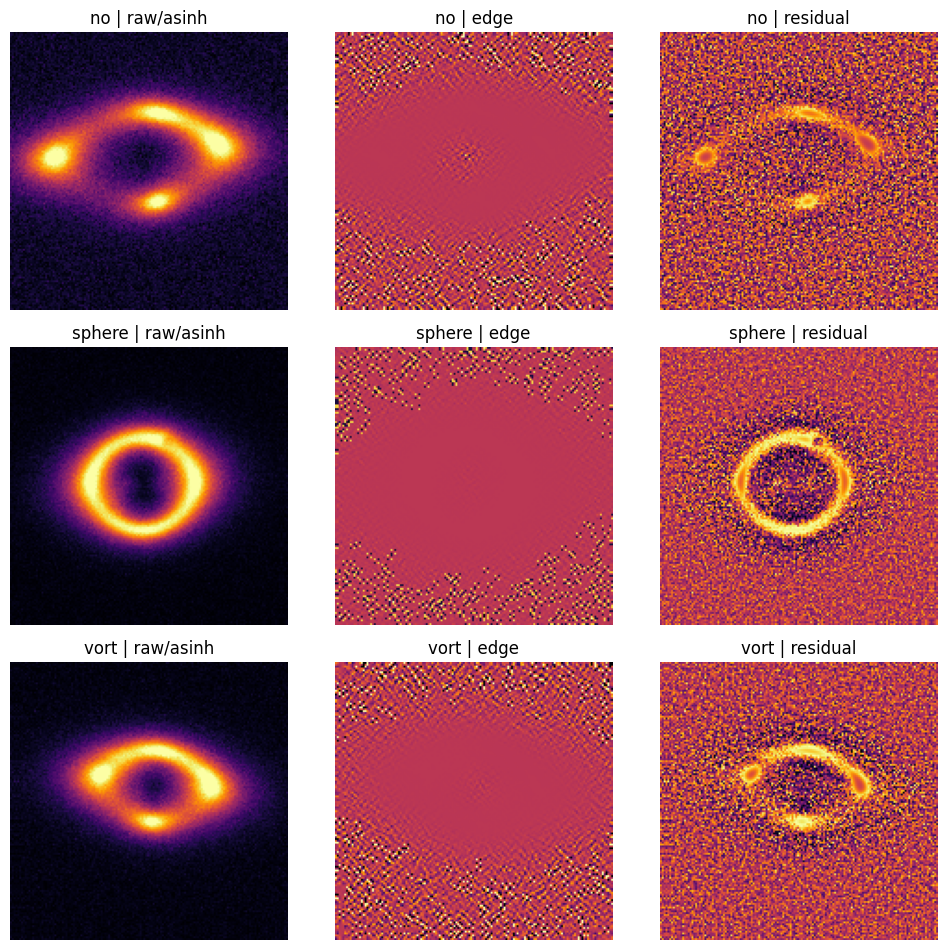

In [10]:

def show_physics_channels(dataset: Dataset, n_per_class: int = 1):
    class_to_indices = defaultdict(list)
    for i, row in dataset.df.iterrows():
        if len(class_to_indices[row.class_name]) < n_per_class:
            class_to_indices[row.class_name].append(i)

    n_rows = len(cfg.class_names)
    fig, axes = plt.subplots(n_rows, 3, figsize=(10, 3.2 * n_rows))
    if n_rows == 1:
        axes = np.expand_dims(axes, 0)

    for r, cls in enumerate(cfg.class_names):
        idx = class_to_indices[cls][0]
        x, _ = dataset[idx]
        x = x.numpy()
        if cfg.normalize_to_minus1_1:
            x = (x * 0.5) + 0.5
        titles = [f"{cls} | raw/asinh", f"{cls} | edge", f"{cls} | residual"]
        for c in range(3):
            axes[r, c].imshow(x[c], cmap="inferno")
            axes[r, c].set_title(titles[c])
            axes[r, c].axis("off")

    plt.tight_layout()
    plt.show()

show_physics_channels(train_ds, n_per_class=1)


In [11]:
def adapt_densenet_small_image_stem(model: nn.Module) -> nn.Module:
    """
    Replace the ImageNet-style 7x7/stride-2 stem with a smaller-image-friendly
    3x3/stride-1 stem, and remove the first max-pool.

    This preserves more spatial detail for subtle substructure patterns in 150x150 images.
    """
    if not (hasattr(model, "features") and hasattr(model.features, "conv0")):
        return model

    old_conv = model.features.conv0
    new_conv = nn.Conv2d(
        in_channels=old_conv.in_channels,
        out_channels=old_conv.out_channels,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False,
    )

    with torch.no_grad():
        # initialize from the central 3x3 crop of the pretrained 7x7 filter bank
        if old_conv.weight.shape[-1] >= 3:
            center = old_conv.weight[:, :, 2:5, 2:5].clone()
            old_std = old_conv.weight.std().clamp_min(1e-6)
            center_std = center.std().clamp_min(1e-6)
            center = center * (old_std / center_std)
            new_conv.weight.copy_(center)
        else:
            nn.init.kaiming_normal_(new_conv.weight, mode="fan_out", nonlinearity="relu")

    model.features.conv0 = new_conv

    # if hasattr(model.features, "pool0"):
    #     model.features.pool0 = nn.Identity()

    return model


def build_model() -> nn.Module:
    model = timm.create_model(
        cfg.model_name,
        pretrained=cfg.pretrained,
        in_chans=cfg.in_chans,
        num_classes=len(cfg.class_names),
        drop_rate=cfg.drop_rate,
        global_pool=cfg.global_pool,
    )

    if cfg.use_small_image_stem:
        model = adapt_densenet_small_image_stem(model)

    return model


model = build_model()
n_params_m = sum(p.numel() for p in model.parameters()) / 1e6
print(f"{cfg.model_name} params (M): {n_params_m:.2f}")
print(f"global_pool: {cfg.global_pool}")
print(f"use_small_image_stem: {cfg.use_small_image_stem}")
del model
gc.collect()

model.safetensors:   0%|          | 0.00/116M [00:00<?, ?B/s]

densenet161 params (M): 26.47
global_pool: catavgmax
use_small_image_stem: True


20679

In [12]:

def compute_auc_metrics(y_true: np.ndarray, y_prob: np.ndarray, class_names: tuple[str, ...]):
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    metrics = {
        "accuracy": float(accuracy_score(y_true, y_prob.argmax(axis=1))),
        "macro_f1": float(f1_score(y_true, y_prob.argmax(axis=1), average="macro")),
        "macro_auc_ovr": float(
            roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
        ),
        "weighted_auc_ovr": float(
            roc_auc_score(y_true_bin, y_prob, average="weighted", multi_class="ovr")
        ),
    }

    per_class_auc = {}
    for i, cls in enumerate(class_names):
        per_class_auc[cls] = float(roc_auc_score(y_true_bin[:, i], y_prob[:, i]))

    return metrics, per_class_auc


def plot_multiclass_roc(y_true: np.ndarray, y_prob: np.ndarray, class_names: tuple[str, ...]):
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        auc_i = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f"{cls} | AUC={auc_i:.5f}")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("One-vs-Rest ROC curves")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, class_names: tuple[str, ...]):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    plt.tight_layout()
    plt.show()


In [13]:

@torch.no_grad()
def predict_proba(model: nn.Module, loader: DataLoader, use_d4_tta: bool = False):
    model.eval()
    probs_all, labels_all = [], []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=(device.type == "cuda"))

        if not use_d4_tta:
            logits = model(xb)
            prob = torch.softmax(logits, dim=1)
        else:
            prob_sum = 0.0
            n_views = 0
            for k in range(4):
                xr = torch.rot90(xb, k=k, dims=(2, 3))
                prob_sum = prob_sum + torch.softmax(model(xr), dim=1)
                n_views += 1

                xf = torch.flip(xr, dims=(3,))
                prob_sum = prob_sum + torch.softmax(model(xf), dim=1)
                n_views += 1

            prob = prob_sum / n_views

        probs_all.append(prob.cpu().numpy())
        labels_all.append(yb.numpy())

    y_true = np.concatenate(labels_all)
    y_prob = np.concatenate(probs_all)
    return y_true, y_prob


@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, criterion=None, use_d4_tta: bool = False):
    model.eval()
    all_true, all_prob = [], []
    val_loss_sum = 0.0
    val_count = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=(device.type == "cuda"))
        yb = yb.to(device, non_blocking=(device.type == "cuda"))

        if not use_d4_tta:
            logits = model(xb)
            prob = torch.softmax(logits, dim=1)
        else:
            prob_sum = 0.0
            logits_sum = 0.0
            n_views = 0
            for k in range(4):
                xr = torch.rot90(xb, k=k, dims=(2, 3))
                logits_r = model(xr)
                prob_sum = prob_sum + torch.softmax(logits_r, dim=1)
                logits_sum = logits_sum + logits_r
                n_views += 1

                xf = torch.flip(xr, dims=(3,))
                logits_f = model(xf)
                prob_sum = prob_sum + torch.softmax(logits_f, dim=1)
                logits_sum = logits_sum + logits_f
                n_views += 1

            prob = prob_sum / n_views
            logits = logits_sum / n_views

        if criterion is not None:
            loss = criterion(logits, yb)
            val_loss_sum += loss.item() * xb.size(0)
            val_count += xb.size(0)

        all_true.append(yb.cpu().numpy())
        all_prob.append(prob.cpu().numpy())

    y_true = np.concatenate(all_true)
    y_prob = np.concatenate(all_prob)
    metrics, per_class_auc = compute_auc_metrics(y_true, y_prob, cfg.class_names)
    val_loss = val_loss_sum / max(1, val_count) if criterion is not None else np.nan
    return val_loss, y_true, y_prob, metrics, per_class_auc


In [14]:

def save_topk_checkpoint(topk_heap, metric_value, save_path, payload, k):
    metric_value = float(metric_value)
    heapq.heappush(topk_heap, (metric_value, str(save_path)))
    torch.save(payload, save_path)

    if len(topk_heap) > k:
        worst_metric, worst_path = heapq.heappop(topk_heap)
        if Path(worst_path).exists() and worst_path != str(save_path):
            Path(worst_path).unlink()


def train_one_run():
    model = build_model().to(device)
    ema = ModelEmaV2(model, decay=cfg.ema_decay) if cfg.use_ema else None

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )

    train_criterion = LabelSmoothingCrossEntropy(smoothing=cfg.label_smoothing)
    eval_criterion = nn.CrossEntropyLoss()
    scaler = GradScaler(enabled=cfg.use_amp and device.type == "cuda")

    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer,
        start_factor=0.2,
        end_factor=1.0,
        total_iters=max(1, cfg.warmup_epochs),
    )
    cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(1, cfg.epochs - cfg.warmup_epochs),
        eta_min=cfg.min_lr,
    )
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[cfg.warmup_epochs],
    )

    best_score = -np.inf
    best_epoch = -1
    best_state = None
    history = []
    patience_counter = 0
    topk_heap = []

    for epoch in range(cfg.epochs):
        model.train()
        running_loss = 0.0
        n_seen = 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=(device.type == "cuda"))
            yb = yb.to(device, non_blocking=(device.type == "cuda"))

            optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=cfg.use_amp and device.type == "cuda"):
                logits = model(xb)
                loss = train_criterion(logits, yb)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(optimizer)
            scaler.update()

            if ema is not None:
                ema.update(model)

            running_loss += loss.item() * xb.size(0)
            n_seen += xb.size(0)

        scheduler.step()

        eval_model = ema.module if ema is not None else model
        val_loss, y_true_val, y_prob_val, metrics, per_class_auc = evaluate_model(
            eval_model,
            val_loader,
            criterion=eval_criterion,
            use_d4_tta=False,
        )

        train_loss = running_loss / max(1, n_seen)
        epoch_record = {
            "epoch": epoch + 1,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
            **metrics,
            **{f"auc_{k}": v for k, v in per_class_auc.items()},
        }
        history.append(epoch_record)

        score = metrics["macro_auc_ovr"]

        print(
            f"{cfg.model_name} | epoch {epoch+1}: "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={metrics['accuracy']:.4f} | "
            f"val_macro_f1={metrics['macro_f1']:.4f} | "
            f"val_macro_auc={metrics['macro_auc_ovr']:.4f}"
        )
        print("per-class AUC:", per_class_auc)

        ckpt_name = f"{cfg.model_name}_epoch{epoch+1:02d}_auc{score:.6f}.pth"
        ckpt_path = Path(cfg.ckpt_dir) / ckpt_name
        payload = {
            "model_state_dict": copy.deepcopy(eval_model.state_dict()),
            "cfg": asdict(cfg),
            "best_epoch": epoch + 1,
            "best_macro_auc_ovr": float(score),
        }
        save_topk_checkpoint(topk_heap, score, ckpt_path, payload, cfg.save_top_k)

        if score > best_score:
            best_score = score
            best_epoch = epoch + 1
            patience_counter = 0
            best_state = payload
            torch.save(best_state, Path(cfg.output_dir) / f"best_{cfg.model_name}_physics_3ch.pth")
        else:
            patience_counter += 1

        if patience_counter >= cfg.early_stopping_patience:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv(Path(cfg.output_dir) / "training_history.csv", index=False)

    topk_sorted = sorted(topk_heap, key=lambda x: x[0], reverse=True)
    topk_df = pd.DataFrame([
        {"macro_auc_ovr": metric, "checkpoint_path": path}
        for metric, path in topk_sorted
    ])
    topk_df.to_csv(Path(cfg.output_dir) / "topk_checkpoints.csv", index=False)

    print(f"\nBest epoch: {best_epoch}")
    print(f"Best macro OvR AUC: {best_score:.6f}")

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return best_state, history_df, topk_df

best_state, history_df, topk_df = train_one_run()


## Train

This notebook now trains with the full Tier-1 recipe:
- **DenseNet161**
- **small-image stem**
- **`catavgmax` pooling**
- **40 epochs / patience 10**
- **top-k checkpoint saving**
- **final top-k checkpoint ensemble + D4 TTA**

Uncomment the training line in the cell above if you want to train from scratch.

After training, the notebook will save:
- `training_history.csv`
- `best_<model>_physics_3ch.pth`
- `topk_checkpoints.csv`
- `final_metrics.json`
- `val_predictions.csv`
- the train/val split CSVs

In [14]:
# Run after training
# display(history_df)
# topk_df
#
# The final evaluation cell below will automatically compare:
# 1) best checkpoint without TTA
# 2) best checkpoint with D4 TTA
# 3) top-k checkpoint ensemble with D4 TTA
from pathlib import Path

print(Path("/kaggle/working/outputs").exists())
print(Path("/kaggle/working/outputs/checkpoints").exists())
print(Path("/kaggle/working/outputs/training_history.csv").exists())
print(Path("/kaggle/working/outputs/topk_checkpoints.csv").exists())
print(Path("/kaggle/working/outputs/splits/val_split.csv").exists())
print(Path(f"/kaggle/working/outputs/best_{cfg.model_name}_physics_3ch.pth").exists())

True
True
False
False
True
False


In [15]:
from pathlib import Path
import os

ckpt_dir = Path("/kaggle/working/outputs/checkpoints")
print("checkpoint dir exists:", ckpt_dir.exists())
print("checkpoint dir:", ckpt_dir)

if ckpt_dir.exists():
    files = sorted(ckpt_dir.glob("*"))
    print(f"\nFound {len(files)} files:\n")
    for f in files:
        size_mb = f.stat().st_size / (1024**2)
        print(f"{f.name:70s}  {size_mb:8.2f} MB")
else:
    print("Checkpoint directory does not exist.")

checkpoint dir exists: True
checkpoint dir: /kaggle/working/outputs/checkpoints

Found 0 files:



In [16]:

def load_checkpoint_model(ckpt_path: str | Path) -> nn.Module:
    bundle = torch.load(ckpt_path, map_location=device)
    model = build_model().to(device)
    model.load_state_dict(bundle["model_state_dict"])
    model.eval()
    return model, bundle


@torch.no_grad()
def ensemble_predict_proba(ckpt_paths, loader: DataLoader, use_d4_tta: bool = True):
    prob_sum = None
    y_true_ref = None
    n_models = 0

    for ckpt_path in ckpt_paths:
        model, _ = load_checkpoint_model(ckpt_path)
        y_true, y_prob = predict_proba(model, loader, use_d4_tta=use_d4_tta)
        prob_sum = y_prob if prob_sum is None else (prob_sum + y_prob)
        y_true_ref = y_true
        n_models += 1
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return y_true_ref, prob_sum / max(1, n_models)


def summarize_predictions(tag: str, y_true: np.ndarray, y_prob: np.ndarray):
    y_pred = y_prob.argmax(axis=1)
    metrics, per_class_auc = compute_auc_metrics(y_true, y_prob, cfg.class_names)
    print("=" * 70)
    print(tag)
    print(json.dumps(metrics, indent=2))
    print("per-class AUC:")
    print(json.dumps(per_class_auc, indent=2))
    print(classification_report(y_true, y_pred, target_names=cfg.class_names, digits=5))
    plot_multiclass_roc(y_true, y_prob, cfg.class_names)
    plot_confusion_matrix(y_true, y_pred, cfg.class_names)
    return metrics, per_class_auc, y_pred


In [17]:

def plot_history(history_df: pd.DataFrame):
    display(history_df)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    axes[0].set_title(f"{cfg.model_name} loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["macro_auc_ovr"], label="val_macro_auc")
    axes[1].plot(history_df["epoch"], history_df["accuracy"], label="val_acc")
    axes[1].plot(history_df["epoch"], history_df["macro_f1"], label="val_macro_f1")
    axes[1].set_title(f"{cfg.model_name} metrics")
    axes[1].set_xlabel("epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# plot_history(history_df)


## If training is done


In [26]:
# Final evaluation after training (FAST VERSION: best checkpoint only)
# If you are evaluating from attached input artifacts, use:
# best_ckpt_path = ARTIFACT_ROOT / "best_densenet161_physics_3ch.pth"
# Otherwise, if the checkpoint is in outputs/, keep the cfg.output_dir version below.

best_ckpt_path = Path(cfg.output_dir) / f"best_{cfg.model_name}_physics_3ch.pth"

best_model, best_bundle = load_checkpoint_model(best_ckpt_path)
ce_criterion = nn.CrossEntropyLoss()

# 1) single best checkpoint, no TTA
val_loss_plain, y_true_plain, y_prob_plain, metrics_plain, per_class_auc_plain = evaluate_model(
    best_model,
    val_loader,
    criterion=ce_criterion,
    use_d4_tta=False,
)
print(
    f"{cfg.model_name} | epoch {int(best_bundle['best_epoch'])} | no_tta: "
    f"val_loss={val_loss_plain:.4f} | "
    f"val_acc={metrics_plain['accuracy']:.4f} | "
    f"val_macro_f1={metrics_plain['macro_f1']:.4f} | "
    f"val_macro_auc={metrics_plain['macro_auc_ovr']:.4f}"
)
print("per-class AUC (no_tta):", per_class_auc_plain)

# 2) single best checkpoint, D4 TTA
_, y_true_tta, y_prob_tta, metrics_tta, per_class_auc_tta = evaluate_model(
    best_model,
    val_loader,
    criterion=None,
    use_d4_tta=True,   # force D4 TTA explicitly
)

print(
    f"{cfg.model_name} | epoch {int(best_bundle['best_epoch'])} | d4_tta: "
    f"val_acc={metrics_tta['accuracy']:.4f} | "
    f"val_macro_f1={metrics_tta['macro_f1']:.4f} | "
    f"val_macro_auc={metrics_tta['macro_auc_ovr']:.4f}"
)
print("per-class AUC (d4_tta):", per_class_auc_tta)

del best_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

summary_rows = [
    {"setting": "best_ckpt_no_tta", **metrics_plain},
    {"setting": "best_ckpt_d4_tta", **metrics_tta},
]
summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("macro_auc_ovr", ascending=False)
    .reset_index(drop=True)
)

print("Final setting comparison:")
display(summary_df)

best_setting = summary_df.iloc[0]["setting"]
if best_setting == "best_ckpt_no_tta":
    final_y_true, final_y_prob = y_true_plain, y_prob_plain
else:
    final_y_true, final_y_prob = y_true_tta, y_prob_tta

final_metrics, final_per_class_auc, final_y_pred = summarize_predictions(
    best_setting,
    final_y_true,
    final_y_prob,
)

final_payload = {
    "model_name": cfg.model_name,
    "best_epoch": int(best_bundle["best_epoch"]),
    "selected_setting": best_setting,
    "summary_table": summary_df.to_dict(orient="records"),
    "final_metrics": final_metrics,
    "final_per_class_auc": final_per_class_auc,
    "checkpoint_paths_used": [str(best_ckpt_path)],
    "notes": {
        "small_image_stem": getattr(cfg, "use_small_image_stem", None),
        "global_pool": getattr(cfg, "global_pool", None),
        "use_d4_tta": True,
        "used_topk_ensemble": False,
    },
}

with open(Path(cfg.output_dir) / "final_metrics.json", "w") as f:
    json.dump(final_payload, f, indent=2)

pred_df = pd.DataFrame({
    "path": val_df["path"],
    "true_label": final_y_true,
    "pred_label": final_y_pred,
    "prob_no": final_y_prob[:, 0],
    "prob_sphere": final_y_prob[:, 1],
    "prob_vort": final_y_prob[:, 2],
})
pred_df.to_csv(Path(cfg.output_dir) / "val_predictions.csv", index=False)

print("\nSelected final setting:", best_setting)
print("Checkpoint used:", best_ckpt_path)

RuntimeError: DataLoader worker (pid(s) 144, 145, 146, 147) exited unexpectedly

# If model_weights are present in input


In [18]:
from pathlib import Path
import os

# -----------------------------
# Find attached artifact root automatically
# -----------------------------
best_ckpt_candidates = sorted(Path("/kaggle/input").rglob("best_densenet161_physics_3ch.pth"))
assert len(best_ckpt_candidates) > 0, "Could not find best_densenet161_physics_3ch.pth in /kaggle/input"

ARTIFACT_ROOT = best_ckpt_candidates[0].parent
ARTIFACT_CKPT_DIR = ARTIFACT_ROOT / "checkpoints"
ARTIFACT_SPLIT_DIR = ARTIFACT_ROOT / "splits"

# writable output dir for this eval-only session
EVAL_OUTPUT_DIR = Path("/kaggle/working/final_eval_outputs")
EVAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("ARTIFACT_ROOT      =", ARTIFACT_ROOT)
print("ARTIFACT_CKPT_DIR  =", ARTIFACT_CKPT_DIR)
print("ARTIFACT_SPLIT_DIR =", ARTIFACT_SPLIT_DIR)
print("EVAL_OUTPUT_DIR    =", EVAL_OUTPUT_DIR)

# Use the saved split from the attached artifacts
cfg.split_csv_dir = str(ARTIFACT_SPLIT_DIR)

# Save new eval outputs here
cfg.output_dir = str(EVAL_OUTPUT_DIR)

# This is only for reference in eval mode
if hasattr(cfg, "ckpt_dir"):
    cfg.ckpt_dir = str(ARTIFACT_CKPT_DIR)




ARTIFACT_ROOT      = /kaggle/input/datasets/ashaeyx/model-weights/Model_weights
ARTIFACT_CKPT_DIR  = /kaggle/input/datasets/ashaeyx/model-weights/Model_weights/checkpoints
ARTIFACT_SPLIT_DIR = /kaggle/input/datasets/ashaeyx/model-weights/Model_weights/splits
EVAL_OUTPUT_DIR    = /kaggle/working/final_eval_outputs


In [19]:
from pathlib import Path
import pandas as pd
import torch
from torch.utils.data import DataLoader

# --------------------------------------------------
# Force evaluation to use the SAVED validation split
# from attached artifacts, and rebuild val_loader
# in single-process mode to avoid worker crashes
# --------------------------------------------------

history_df = pd.read_csv(ARTIFACT_ROOT / "training_history.csv")
val_df = pd.read_csv(ARTIFACT_SPLIT_DIR / "val_split.csv")

DATASET_ROOT = find_dataset_root(cfg.data_root)
print("DATASET_ROOT:", DATASET_ROOT)

def remap_to_current_dataset(p):
    p = Path(str(p))
    if p.exists():
        return str(p)

    s = str(p).replace("\\", "/")

    # Case 1: old absolute path contains /dataset/
    if "/dataset/" in s:
        rel = s.split("/dataset/", 1)[1]
        cand = DATASET_ROOT / rel
        if cand.exists():
            return str(cand)

    # Case 2: path contains train/... or val/... somewhere
    parts = p.parts
    for split_name in ("train", "val"):
        if split_name in parts:
            idx = parts.index(split_name)
            cand = DATASET_ROOT.joinpath(*parts[idx:])
            if cand.exists():
                return str(cand)

    raise FileNotFoundError(f"Could not resolve dataset path: {p}")

val_df["path"] = val_df["path"].apply(remap_to_current_dataset)

missing_mask = ~val_df["path"].apply(lambda x: Path(x).exists())
print("Missing validation files:", int(missing_mask.sum()))
assert missing_mask.sum() == 0, "Some validation image paths are still missing."

# Rebuild validation dataset/loader safely for eval-only session
val_ds = LensPhysicsDataset(val_df, train=False)
val_loader = DataLoader(
    val_ds,
    batch_size=min(cfg.batch_size, 16),   # keep reasonable for eval
    shuffle=False,
    num_workers=0,                        # IMPORTANT: avoid worker crashes
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
    persistent_workers=False,
)

print("Rebuilt val_loader safely.")
print("Validation samples:", len(val_ds))
print("Validation batches:", len(val_loader))
print(val_df.head())

DATASET_ROOT: /kaggle/input/datasets/ashaeyx/common-task-dataset/dataset
Missing validation files: 0
Rebuilt val_loader safely.
Validation samples: 3750
Validation batches: 469
                                                path  label class_name  \
0  /kaggle/input/datasets/ashaeyx/common-task-dat...      2       vort   
1  /kaggle/input/datasets/ashaeyx/common-task-dat...      0         no   
2  /kaggle/input/datasets/ashaeyx/common-task-dat...      1     sphere   
3  /kaggle/input/datasets/ashaeyx/common-task-dat...      1     sphere   
4  /kaggle/input/datasets/ashaeyx/common-task-dat...      2       vort   

     source_split  
0  provided_train  
1  provided_train  
2  provided_train  
3  provided_train  
4  provided_train  


densenet161 | epoch 34 | no_tta: val_loss=0.1084 | val_acc=0.9704 | val_macro_f1=0.9704 | val_macro_auc=0.9968
per-class AUC (no_tta): {'no': 0.9970544, 'sphere': 0.9952870400000001, 'vort': 0.99809248}
densenet161 | epoch 34 | d4_tta: val_acc=0.9731 | val_macro_f1=0.9731 | val_macro_auc=0.9976
per-class AUC (d4_tta): {'no': 0.99746528, 'sphere': 0.99636512, 'vort': 0.9990697599999999}
Final setting comparison:


,setting,accuracy,macro_f1,macro_auc_ovr,weighted_auc_ovr
0,best_ckpt_d4_tta,0.973067,0.973071,0.997633,0.997633
1,best_ckpt_no_tta,0.970400,0.970372,0.996811,0.996811


best_ckpt_d4_tta
{
  "accuracy": 0.9730666666666666,
  "macro_f1": 0.9730707180424307,
  "macro_auc_ovr": 0.9976333866666667,
  "weighted_auc_ovr": 0.9976333866666667
}
per-class AUC:
{
  "no": 0.99746528,
  "sphere": 0.99636512,
  "vort": 0.9990697599999999
}
              precision    recall  f1-score   support

          no    0.94047   0.99840   0.96857      1250
      sphere    0.98824   0.94080   0.96393      1250
        vort    0.99351   0.98000   0.98671      1250

    accuracy                        0.97307      3750
   macro avg    0.97407   0.97307   0.97307      3750
weighted avg    0.97407   0.97307   0.97307      3750



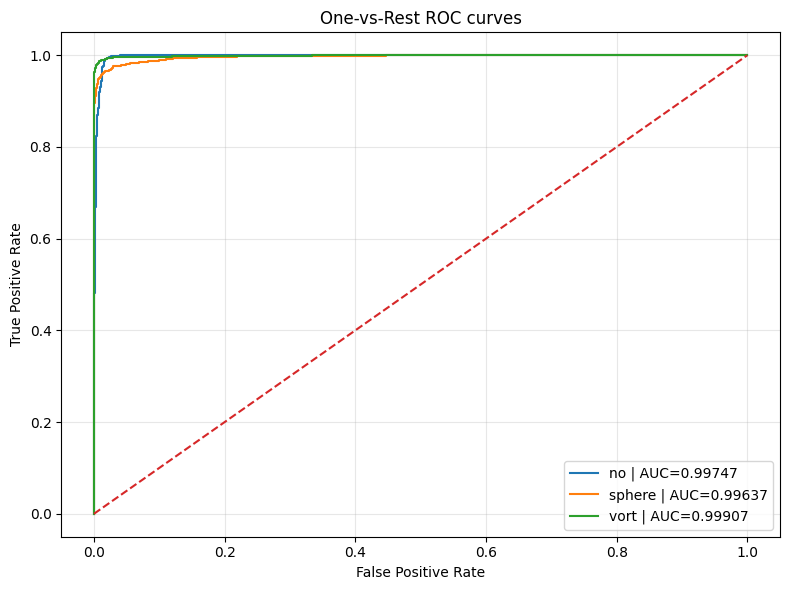

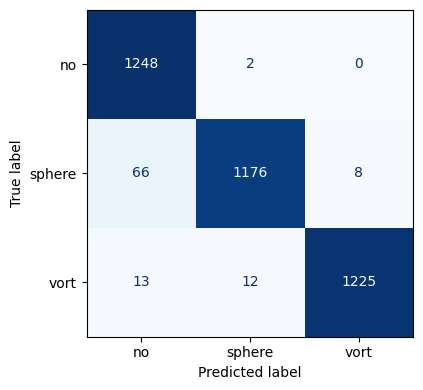


Selected final setting: best_ckpt_d4_tta
Checkpoint used: /kaggle/input/datasets/ashaeyx/model-weights/Model_weights/best_densenet161_physics_3ch.pth


In [20]:

# Final evaluation after training (FAST VERSION: best checkpoint only)
# If you are evaluating from attached input artifacts, use:
# best_ckpt_path = ARTIFACT_ROOT / "best_densenet161_physics_3ch.pth"
# Otherwise, if the checkpoint is in outputs/, keep the cfg.output_dir version below.

best_ckpt_path = ARTIFACT_ROOT / "best_densenet161_physics_3ch.pth"

best_model, best_bundle = load_checkpoint_model(best_ckpt_path)
ce_criterion = nn.CrossEntropyLoss()

# 1) single best checkpoint, no TTA
val_loss_plain, y_true_plain, y_prob_plain, metrics_plain, per_class_auc_plain = evaluate_model(
    best_model,
    val_loader,
    criterion=ce_criterion,
    use_d4_tta=False,
)
print(
    f"{cfg.model_name} | epoch {int(best_bundle['best_epoch'])} | no_tta: "
    f"val_loss={val_loss_plain:.4f} | "
    f"val_acc={metrics_plain['accuracy']:.4f} | "
    f"val_macro_f1={metrics_plain['macro_f1']:.4f} | "
    f"val_macro_auc={metrics_plain['macro_auc_ovr']:.4f}"
)
print("per-class AUC (no_tta):", per_class_auc_plain)

# 2) single best checkpoint, D4 TTA
_, y_true_tta, y_prob_tta, metrics_tta, per_class_auc_tta = evaluate_model(
    best_model,
    val_loader,
    criterion=None,
    use_d4_tta=True,   # force D4 TTA explicitly
)

print(
    f"{cfg.model_name} | epoch {int(best_bundle['best_epoch'])} | d4_tta: "
    f"val_acc={metrics_tta['accuracy']:.4f} | "
    f"val_macro_f1={metrics_tta['macro_f1']:.4f} | "
    f"val_macro_auc={metrics_tta['macro_auc_ovr']:.4f}"
)
print("per-class AUC (d4_tta):", per_class_auc_tta)

del best_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

summary_rows = [
    {"setting": "best_ckpt_no_tta", **metrics_plain},
    {"setting": "best_ckpt_d4_tta", **metrics_tta},
]
summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("macro_auc_ovr", ascending=False)
    .reset_index(drop=True)
)

print("Final setting comparison:")
display(summary_df)

best_setting = summary_df.iloc[0]["setting"]
if best_setting == "best_ckpt_no_tta":
    final_y_true, final_y_prob = y_true_plain, y_prob_plain
else:
    final_y_true, final_y_prob = y_true_tta, y_prob_tta

final_metrics, final_per_class_auc, final_y_pred = summarize_predictions(
    best_setting,
    final_y_true,
    final_y_prob,
)

final_payload = {
    "model_name": cfg.model_name,
    "best_epoch": int(best_bundle["best_epoch"]),
    "selected_setting": best_setting,
    "summary_table": summary_df.to_dict(orient="records"),
    "final_metrics": final_metrics,
    "final_per_class_auc": final_per_class_auc,
    "checkpoint_paths_used": [str(best_ckpt_path)],
    "notes": {
        "small_image_stem": getattr(cfg, "use_small_image_stem", None),
        "global_pool": getattr(cfg, "global_pool", None),
        "use_d4_tta": True,
        "used_topk_ensemble": False,
    },
}

with open(Path(cfg.output_dir) / "final_metrics.json", "w") as f:
    json.dump(final_payload, f, indent=2)

pred_df = pd.DataFrame({
    "path": val_df["path"],
    "true_label": final_y_true,
    "pred_label": final_y_pred,
    "prob_no": final_y_prob[:, 0],
    "prob_sphere": final_y_prob[:, 1],
    "prob_vort": final_y_prob[:, 2],
})
pred_df.to_csv(Path(cfg.output_dir) / "val_predictions.csv", index=False)

print("\nSelected final setting:", best_setting)
print("Checkpoint used:", best_ckpt_path)


Selected final setting: best_ckpt_d4_tta
Best epoch: 34

Final metrics:
accuracy: 0.973067
macro_f1: 0.973071
macro_auc_ovr: 0.997633
weighted_auc_ovr: 0.997633

Per-class AUC:
no: 0.997465
sphere: 0.996365
vort: 0.999070

Classification report:
              precision    recall  f1-score   support

          no     0.9405    0.9984    0.9686      1250
      sphere     0.9882    0.9408    0.9639      1250
        vort     0.9935    0.9800    0.9867      1250

    accuracy                         0.9731      3750
   macro avg     0.9741    0.9731    0.9731      3750
weighted avg     0.9741    0.9731    0.9731      3750



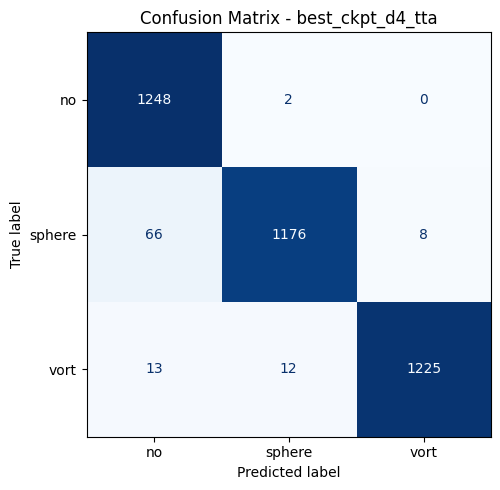

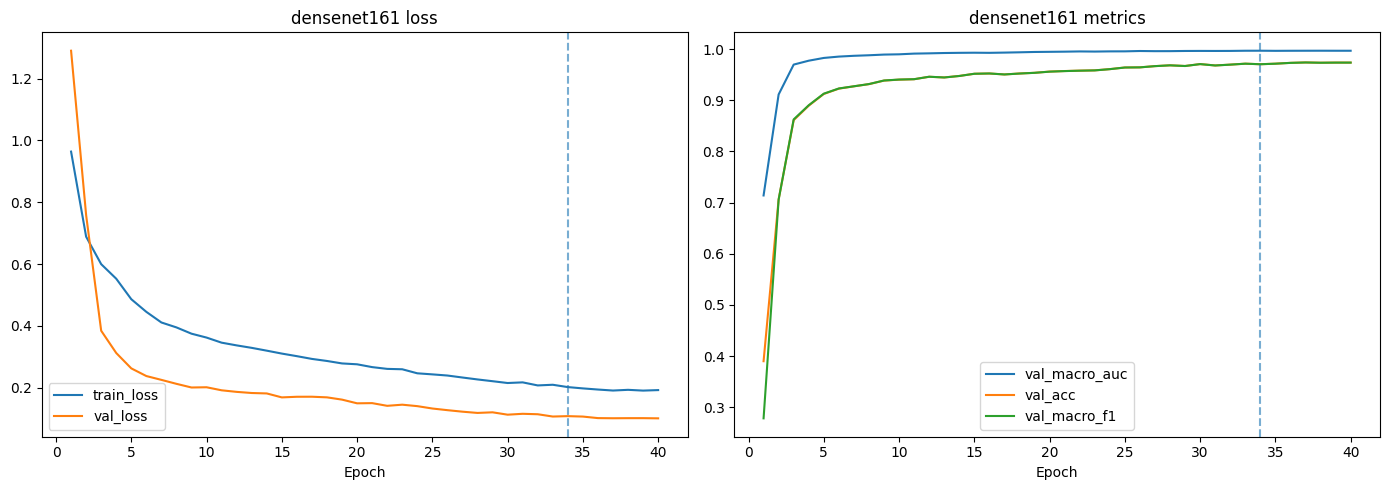

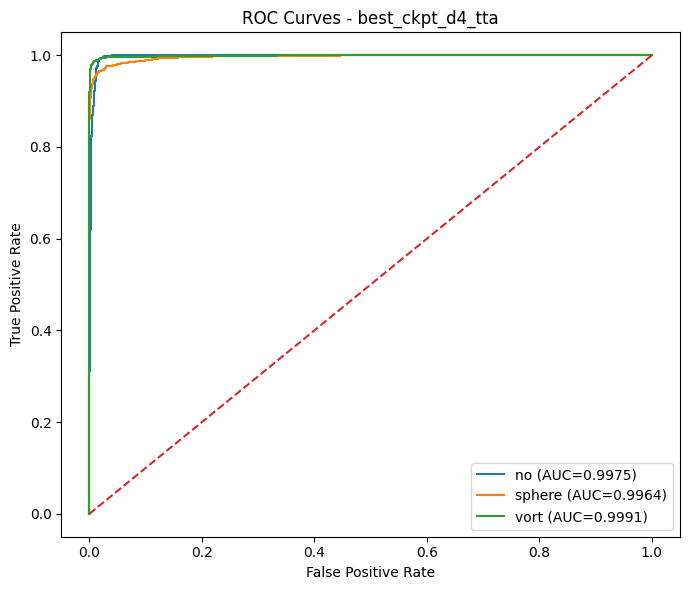


Saved plot files:
/kaggle/working/final_eval_outputs/confusion_matrix.png
/kaggle/working/final_eval_outputs/training_curves.png
/kaggle/working/final_eval_outputs/roc_curves.png


In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize

# -----------------------------
# Text metrics
# -----------------------------
print("\nSelected final setting:", best_setting)
print("Best epoch:", int(best_bundle["best_epoch"]))

print("\nFinal metrics:")
for k, v in final_metrics.items():
    if isinstance(v, (int, float, np.floating)):
        print(f"{k}: {v:.6f}")
    else:
        print(f"{k}: {v}")

print("\nPer-class AUC:")
for cls_name, auc_val in final_per_class_auc.items():
    print(f"{cls_name}: {auc_val:.6f}")

print("\nClassification report:")
print(
    classification_report(
        final_y_true,
        final_y_pred,
        target_names=list(cfg.class_names),
        digits=4
    )
)

# -----------------------------
# Confusion matrix
# -----------------------------
cm = confusion_matrix(
    final_y_true,
    final_y_pred,
    labels=np.arange(len(cfg.class_names))
)

fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(cfg.class_names)
)
disp.plot(ax=ax_cm, cmap="Blues", colorbar=False, values_format="d")
ax_cm.set_title(f"Confusion Matrix - {best_setting}")
plt.tight_layout()
fig_cm.savefig(Path(cfg.output_dir) / "confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

# -----------------------------
# Training curves
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "train_loss" in history_df.columns:
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
if "val_loss" in history_df.columns:
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0].axvline(int(best_bundle["best_epoch"]), linestyle="--", alpha=0.6)
axes[0].set_title(f"{cfg.model_name} loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

if "macro_auc_ovr" in history_df.columns:
    axes[1].plot(history_df["epoch"], history_df["macro_auc_ovr"], label="val_macro_auc")
if "accuracy" in history_df.columns:
    axes[1].plot(history_df["epoch"], history_df["accuracy"], label="val_acc")
if "macro_f1" in history_df.columns:
    axes[1].plot(history_df["epoch"], history_df["macro_f1"], label="val_macro_f1")
axes[1].axvline(int(best_bundle["best_epoch"]), linestyle="--", alpha=0.6)
axes[1].set_title(f"{cfg.model_name} metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(Path(cfg.output_dir) / "training_curves.png", dpi=200, bbox_inches="tight")
plt.show()

# -----------------------------
# ROC curves
# -----------------------------
y_true_bin = label_binarize(final_y_true, classes=np.arange(len(cfg.class_names)))

fig_roc, ax_roc = plt.subplots(figsize=(7, 6))
for i, cls_name in enumerate(cfg.class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], final_y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, label=f"{cls_name} (AUC={roc_auc:.4f})")

ax_roc.plot([0, 1], [0, 1], linestyle="--")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title(f"ROC Curves - {best_setting}")
ax_roc.legend()
plt.tight_layout()
fig_roc.savefig(Path(cfg.output_dir) / "roc_curves.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nSaved plot files:")
print(Path(cfg.output_dir) / "confusion_matrix.png")
print(Path(cfg.output_dir) / "training_curves.png")
print(Path(cfg.output_dir) / "roc_curves.png")

In [20]:
# # Final evaluation after training
# best_ckpt_path = Path(cfg.output_dir) / f"best_{cfg.model_name}_physics_3ch.pth"
# topk_csv_path = Path(cfg.output_dir) / "topk_checkpoints.csv"

# best_model, best_bundle = load_checkpoint_model(best_ckpt_path)
# ce_criterion = nn.CrossEntropyLoss()

# # 1) single best checkpoint, no TTA
# val_loss_plain, y_true_plain, y_prob_plain, metrics_plain, per_class_auc_plain = evaluate_model(
#     best_model,
#     val_loader,
#     criterion=ce_criterion,
#     use_d4_tta=False,
# )
# print(
#     f"{cfg.model_name} | epoch {int(best_bundle['best_epoch'])}: "
#     f"train_loss=see history_df | val_loss={val_loss_plain:.4f} | "
#     f"val_acc={metrics_plain['accuracy']:.4f} | "
#     f"val_macro_f1={metrics_plain['macro_f1']:.4f} | "
#     f"val_macro_auc={metrics_plain['macro_auc_ovr']:.4f}"
# )
# print("per-class AUC:", per_class_auc_plain)

# # 2) single best checkpoint, D4 TTA
# _, y_true_tta, y_prob_tta, metrics_tta, per_class_auc_tta = evaluate_model(
#     best_model,
#     val_loader,
#     criterion=None,
#     use_d4_tta=cfg.use_d4_tta,
# )

# # 3) top-k checkpoint ensemble with D4 TTA
# if topk_csv_path.exists():
#     topk_df = pd.read_csv(topk_csv_path)
#     ckpt_paths = (
#         topk_df.sort_values("macro_auc_ovr", ascending=False)["checkpoint_path"]
#         .tolist()[: cfg.final_eval_top_k]
#     )
# else:
#     ckpt_paths = [str(best_ckpt_path)]

# y_true_ens, y_prob_ens = ensemble_predict_proba(
#     ckpt_paths,
#     val_loader,
#     use_d4_tta=cfg.use_d4_tta,
# )
# metrics_ens, per_class_auc_ens = compute_auc_metrics(y_true_ens, y_prob_ens, cfg.class_names)

# del best_model
# gc.collect()
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()

# summary_rows = [
#     {"setting": "best_ckpt_no_tta", **metrics_plain},
#     {"setting": "best_ckpt_d4_tta", **metrics_tta},
#     {"setting": f"top{len(ckpt_paths)}_ckpt_d4_tta_ensemble", **metrics_ens},
# ]
# summary_df = (
#     pd.DataFrame(summary_rows)
#     .sort_values("macro_auc_ovr", ascending=False)
#     .reset_index(drop=True)
# )
# print("Final setting comparison:")
# display(summary_df)

# best_setting = summary_df.iloc[0]["setting"]
# if best_setting == "best_ckpt_no_tta":
#     final_y_true, final_y_prob = y_true_plain, y_prob_plain
# elif best_setting == "best_ckpt_d4_tta":
#     final_y_true, final_y_prob = y_true_tta, y_prob_tta
# else:
#     final_y_true, final_y_prob = y_true_ens, y_prob_ens

# final_metrics, final_per_class_auc, final_y_pred = summarize_predictions(
#     best_setting,
#     final_y_true,
#     final_y_prob,
# )

# final_payload = {
#     "model_name": cfg.model_name,
#     "best_epoch": int(best_bundle["best_epoch"]),
#     "selected_setting": best_setting,
#     "summary_table": summary_df.to_dict(orient="records"),
#     "final_metrics": final_metrics,
#     "final_per_class_auc": final_per_class_auc,
#     "checkpoint_paths_used": ckpt_paths,
#     "notes": {
#         "small_image_stem": cfg.use_small_image_stem,
#         "global_pool": cfg.global_pool,
#         "use_d4_tta": cfg.use_d4_tta,
#         "final_eval_top_k": cfg.final_eval_top_k,
#     },
# }
# with open(Path(cfg.output_dir) / "final_metrics.json", "w") as f:
#     json.dump(final_payload, f, indent=2)

# pred_df = pd.DataFrame({
#     "path": val_df["path"],
#     "true_label": final_y_true,
#     "pred_label": final_y_pred,
#     "prob_no": final_y_prob[:, 0],
#     "prob_sphere": final_y_prob[:, 1],
#     "prob_vort": final_y_prob[:, 2],
# })
# pred_df.to_csv(Path(cfg.output_dir) / "val_predictions.csv", index=False)

# print("\nSelected final setting:", best_setting)
# print("Checkpoints used:", ckpt_paths)

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/best_densenet161_physics_3ch.pth'

## Practical strategy notes

This notebook now uses the full **Tier-1** configuration because it has the best chance of improving results without destabilizing the backbone:

1. **Keep DenseNet161 as the default** rather than switching to another DenseNet variant.
2. **Preserve early spatial detail** with the **small-image stem**:
   - replace the original aggressive stem,
   - remove the initial max-pool,
   - keep more fine lensing structure alive before the dense blocks.
3. **Use `catavgmax` pooling** so the classifier sees both diffuse/global morphology and localized high-response cues.
4. **Train longer** (**40 epochs**, **patience 10**) because your earlier runs were still improving late.
5. **Use D4 TTA at final inference** because it is a clean, symmetry-respecting boost.
6. **Use top-k checkpoint ensembling** so the final submission depends less on a single lucky or unlucky epoch.
7. **Select the best final inference recipe automatically** by comparing:
   - best checkpoint without TTA,
   - best checkpoint with D4 TTA,
   - top-k checkpoint ensemble with D4 TTA.

### Why the stem change matters
The biggest architecture-side risk in an ImageNet-pretrained DenseNet for this task is **losing small substructure too early**.  
The stem change is meant to fix exactly that while leaving the dense blocks themselves intact.

### Why this is safer than deeper surgery
I did **not** change BatchNorm, activations inside the dense blocks, or the dense connectivity pattern itself.  
Those are much riskier modifications because they move farther away from the pretrained backbone.

### Good follow-up ablations after this notebook
If you want to test more after this:
- compare `catavgmax` vs `avg`,
- compare top-3 vs top-5 checkpoint ensemble,
- compare 30 vs 40 epochs,
- compare raw+edge+residual against a stronger radial-residual third channel.